In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Connect to SQLite database (creates it if it doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create the sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert sample sales data
sample_data = [
    ("Apple", 10, 1.2),
    ("Banana", 15, 0.5),
    ("Apple", 5, 1.2),
    ("Orange", 8, 0.8),
    ("Banana", 20, 0.5),
    ("Orange", 10, 0.8),
    ("Grapes", 12, 2.0)
]

# Clear old data and insert fresh rows
cursor.execute("DELETE FROM sales")
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()


In [5]:
# Query to get total quantity and total revenue by product
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Load the result into a pandas DataFrame
df = pd.read_sql_query(query, conn)

# Show the result
print("Sales Summary:")
print(df)


Sales Summary:
  product  total_qty  revenue
0   Apple         15     18.0
1  Banana         35     17.5
2  Grapes         12     24.0
3  Orange         18     14.4


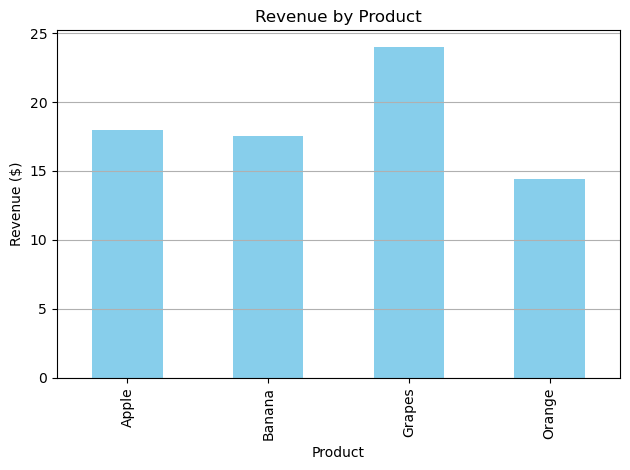

In [7]:
# Plotting the bar chart
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.grid(axis='y')

# Optional: Save the plot
plt.savefig("sales_chart.png")
plt.show()


In [9]:
conn.close()
